# Coursework 2
---
This coursework focuses on applying neural networks to a classification problem where you will **design the dataset yourself**. You are given a small set of example images containing simple shapes, where each image consists of one or more connected components. Two shapes that touch are considered part of the same component (using 4-neighbour connectivity: up, down, left, right). Your task is to generate your own dataset of similar images and train models to predict the number of connected components in each image, grouped into the classes 1, 2 or 3.

This coursework requires you to make a number of design choices. In particular, you will need to decide how to generate images, how to introduce variation (e.g. position, size, noise), and how to ensure your task is non-trivial. You will train and compare a fully connected neural network and a convolutional neural network, and evaluate their performance not only on standard test data but also under a distribution shift of your own design. A key part of the coursework is analysing your results and understanding where and why your models succeed or fail.

The aim of this assignment is not simply to achieve high accuracy, but to demonstrate your understanding of how data, model choice, and evaluation interact in a machine learning pipeline.

In [1]:
import numpy as np
import random
import torch
from torch import nn
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
from scipy.ndimage import label as cc_label
from scipy.ndimage import gaussian_filter, zoom
import copy

## 1. Data generation
---

### 1.2. Create the dataset
First, write a function that creates an image sample given the number of disconnected shapes. If you want, you can create auxiliary functions to be called in the `generate_image` function.

A connected component is defined using 4-neighbour connectivity:
- Each pixel has up to four neighbours: up, down, left, right.
- Two pixels with value 1 belong to the same component if there exists a path of adjacent pixels with value 1, where each step moves between these 4 neighbours. Diagonal connections do not count.

In [2]:
# 4-neighbour connectivity structure (no diagonals)
struct_4 = np.array([[0, 1, 0],
                     [1, 1, 1],
                     [0, 1, 0]], dtype=np.uint8)

def count_components_4(img):
    # Return the number of 4-connected components of the foreground.
    _, n = cc_label((img > 0).astype(np.uint8), structure=struct_4)
    return n


# Shape drawing helpers. Each draws one shape onto the canvas at centre (cy, cx).

def draw_disk(canvas, cy, cx, r):
    H, W = canvas.shape
    y, x = np.ogrid[:H, :W]
    canvas[(y - cy)**2 + (x - cx)**2 <= r*r] = 1.0

def draw_rectangle(canvas, cy, cx, h, w):
    H, W = canvas.shape
    y0, y1 = max(0, cy - h//2), min(H, cy + (h+1)//2)
    x0, x1 = max(0, cx - w//2), min(W, cx + (w+1)//2)
    canvas[y0:y1, x0:x1] = 1.0

def draw_ellipse(canvas, cy, cx, ry, rx):
    H, W = canvas.shape
    y, x = np.ogrid[:H, :W]
    canvas[((y - cy)/ry)**2 + ((x - cx)/rx)**2 <= 1.0] = 1.0

def draw_triangle(canvas, cy, cx, s):
    H, W = canvas.shape
    for i in range(s):
        y = cy - s//2 + i
        if not (0 <= y < H):
            continue
        half = (i + 1)//2 + 1
        canvas[y, max(0, cx - half):min(W, cx + half + 1)] = 1.0

def draw_cross(canvas, cy, cx, s, t):
    draw_rectangle(canvas, cy, cx, t, s)
    draw_rectangle(canvas, cy, cx, s, t)

def draw_l_shape(canvas, cy, cx, s, t):
    H, W = canvas.shape
    y0, y1 = max(0, cy - s//2), min(H, cy + s//2 + 1)
    x0, x1 = max(0, cx - t//2), min(W, cx + t//2 + 1)
    canvas[y0:y1, x0:x1] = 1.0
    y0f = max(0, cy + s//2 - t + 1)
    y1f = min(H, cy + s//2 + 1)
    x0f = max(0, cx - t//2)
    x1f = min(W, cx + s//2 + 1)
    canvas[y0f:y1f, x0f:x1f] = 1.0

def draw_doughnut(canvas, cy, cx, r_outer, r_inner):
    # Annulus: filled disk with a central hole. Still one 4-connected
    # component because the ring is continuous. Chosen deliberately to
    # stress the label definition: a hole is not a second component.
    H, W = canvas.shape
    y, x = np.ogrid[:H, :W]
    dist_sq = (y - cy)**2 + (x - cx)**2
    canvas[(dist_sq <= r_outer*r_outer) & (dist_sq >= r_inner*r_inner)] = 1.0


shape_types = ('disk', 'rectangle', 'ellipse', 'triangle',
               'cross', 'l_shape', 'doughnut')

def draw_random_shape(size):
    # Draw one random shape of random type, size and position.
    canvas = np.zeros((size, size), dtype=np.float32)
    kind = random.choice(shape_types)

    r_min = 2
    r_max = max(3, size//6)
    margin = r_max + 1
    cy = random.randint(margin, size - margin - 1)
    cx = random.randint(margin, size - margin - 1)

    if kind == 'disk':
        draw_disk(canvas, cy, cx, random.randint(r_min, r_max))
    elif kind == 'rectangle':
        draw_rectangle(canvas, cy, cx,
                       random.randint(2*r_min, 2*r_max),
                       random.randint(2*r_min, 2*r_max))
    elif kind == 'ellipse':
        ry = random.randint(r_min, r_max)
        rx = random.randint(r_min, r_max)
        if abs(ry - rx) > r_max:
            rx = ry
        draw_ellipse(canvas, cy, cx, ry, rx)
    elif kind == 'triangle':
        draw_triangle(canvas, cy, cx, random.randint(2*r_min, 2*r_max))
    elif kind == 'cross':
        s = random.randint(2*r_min + 1, 2*r_max + 1)
        t = random.randint(2, max(3, s//2))
        draw_cross(canvas, cy, cx, s, t)
    elif kind == 'l_shape':
        s = random.randint(2*r_min + 1, 2*r_max + 1)
        t = random.randint(2, max(3, s//2))
        draw_l_shape(canvas, cy, cx, s, t)
    elif kind == 'doughnut':
        # minimum ring thickness of 3 px prevents 4-connectivity break
        r_outer = random.randint(r_min + 3, r_max)
        r_inner = random.randint(1, r_outer - 3)
        draw_doughnut(canvas, cy, cx, r_outer, r_inner)

    return canvas

In [3]:
def generate_image(size=32, n_shapes=2):
    if n_shapes not in (1, 2, 3):
        raise ValueError(f"n_shapes must be 1, 2, or 3; got {n_shapes}")

    """
    Requirements:
    - must generate a single image of size (size, size),
    - this image must contain n_shapes shapes,
    - the shapes must include random variations (position, size, etc.)

    Returns:
        np.array of shape (size, size) 
        int label 
    """
    max_outer = 50
    max_inner = 300

    for _ in range(max_outer):
        img = np.zeros((size, size), dtype=np.float32)
        placed = 0
        inner = 0

        while placed < n_shapes and inner < max_inner:
            inner = inner + 1
            cand = draw_random_shape(size)
            if cand.sum() == 0:
                continue
            trial = np.maximum(img, cand)
            # accept only if this shape adds exactly one new component
            if count_components_4(trial) == placed + 1:
                img = trial
                placed = placed + 1

        if placed == n_shapes and count_components_4(img) == n_shapes:
            return img, n_shapes - 1

    # Fallback (very unlikely): three well-separated small disks
    img = np.zeros((size, size), dtype=np.float32)
    for k in range(n_shapes):
        draw_disk(img, size//4 + k*size//4, size//2, 2)
    actual = count_components_4(img)
    if actual != n_shapes:
        raise RuntimeError(
            f"generate_image fallback produced {actual} components, expected {n_shapes}"
        )
    return img, n_shapes - 1

Using the image generating code, generate a dataset class. You can slighlty modify the following codes if needed.

In [4]:
class ComponentsDataset(Dataset):
    """
    PyTorch Dataset for the connected components classification task.
    Each sample consists of:
        - an input image of shape (1, H, W)
        - a target label representing the number of connected components

    Parameters:
    n_samples : int
        Number of samples to generate in the dataset.
    size : int, optional
        Height and width of the generated images (default is 32).

    Attributes:
    images : list of np.ndarray
        List of generated images of shape (H, W).

    labels: list of int
        List of integer class labels in {0,1,2}.

    classes : list of str
        Human-readable class names corresponding to labels.
    """
        
    def __init__(self, n_samples, size=32):
        self.images = []
        self.labels = []
        self.classes = ['1','2','3']

        for _ in range(n_samples):
            n_shapes = random.randint(1, 3)
            img, label = generate_image(size=size, n_shapes=n_shapes)

            self.images.append(img.astype(np.float32))
            self.labels.append(label)

        self.images = np.array(self.images)        # shape: (N, H, W)
        self.labels = np.array(self.labels)  # shape: (N,)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x = torch.tensor(self.images[idx]).unsqueeze(0)  # (1, H, W)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

### 1.2. Describe the data and show examples

**Describe the data that you have generated and show examples using the functions that you have constructed.** 
In the report, you should present and explore the dataset you have generated. This should include visualising a representative set of images from each class and commenting on their characteristics. Your presentation should make clear how the different classes are defined and illustrate the range of variation in your data (e.g. position, size, shape, noise). The aim is to demonstrate that your dataset is meaningful, non-trivial, and consistent with the problem description. 

Label-correctness check: 600/600 images correct


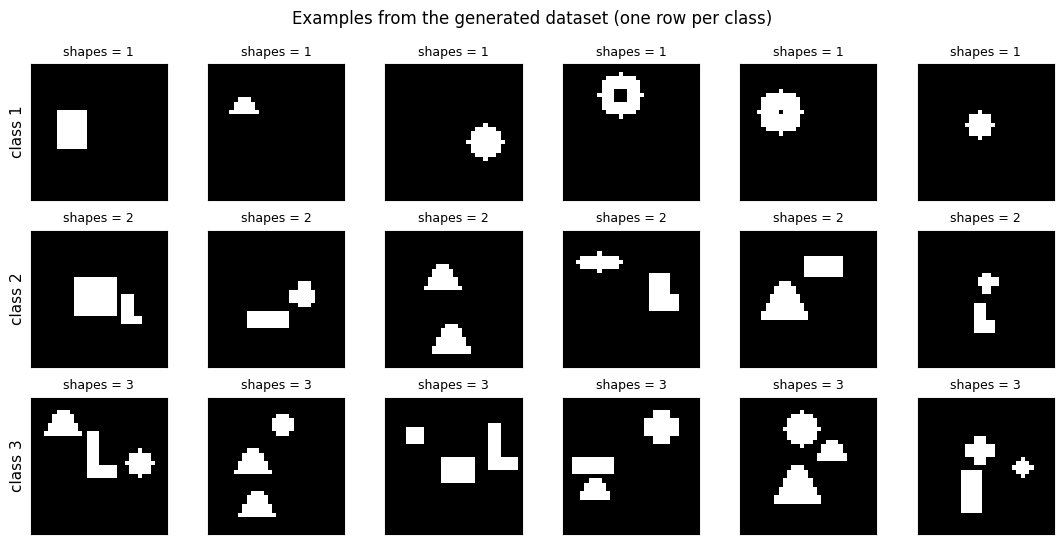

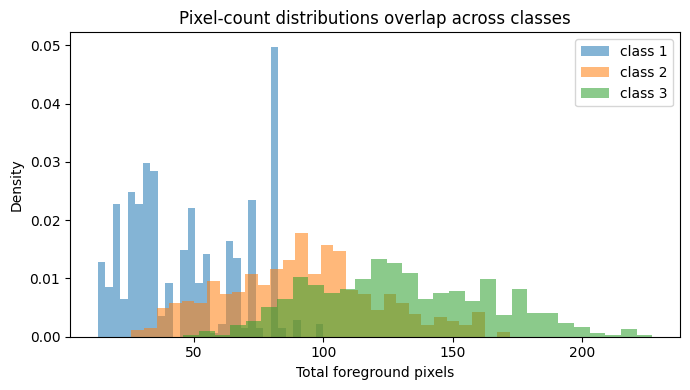

Best two-threshold pixel-count classifier:
  thresholds = (82, 110)
  accuracy   = 0.683
  chance     = 0.333


In [5]:
# ------ Sanity check: every label matches the verified 4-connectivity count ------
random.seed(0); np.random.seed(0)
n_check = 600
mismatches = 0
for _ in range(n_check):
    k = random.randint(1, 3)
    img, label = generate_image(32, k)
    if count_components_4(img) != k or label != k - 1:
        mismatches = mismatches + 1
print(f"Label-correctness check: {n_check - mismatches}/{n_check} images correct")


# ------ Visualise examples: 6 per class ------
random.seed(4); np.random.seed(4)
fig, axes = plt.subplots(3, 6, figsize=(11, 5.5))
for row, k in enumerate([1, 2, 3]):
    for col in range(6):
        img, _ = generate_image(32, k)
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
        axes[row, col].set_title(f'shapes = {k}', fontsize=9)
    axes[row, 0].set_ylabel(f'class {k}', fontsize=11)
plt.suptitle('Examples from the generated dataset (one row per class)')
plt.tight_layout()
plt.show()


# ------ Pixel-count distributions overlap across classes - the task is non-trivial ------
pixel_counts = {1: [], 2: [], 3: []}
for _ in range(1500):
    k = random.randint(1, 3)
    img, _ = generate_image(32, k)
    pixel_counts[k].append(img.sum())

plt.figure(figsize=(7, 4))
for k, c in zip((1, 2, 3), ('tab:blue', 'tab:orange', 'tab:green')):
    plt.hist(pixel_counts[k], bins=30, alpha=0.55, color=c,
             label=f'class {k}', density=True)
plt.xlabel('Total foreground pixels')
plt.ylabel('Density')
plt.title('Pixel-count distributions overlap across classes')
plt.legend()
plt.tight_layout()
plt.show()

# Two-threshold pixel-count classifier - best achievable accuracy using
# only the total foreground pixel count as a feature. This quantifies the
# difficulty of the task: a low number here means structural inference is
# genuinely required, not just aggregation.

# Flatten pixel_counts dict into parallel arrays
pixel_arr = np.concatenate([pixel_counts[k] for k in (1, 2, 3)])
label_arr = np.concatenate([np.full(len(pixel_counts[k]), k - 1) for k in (1, 2, 3)])

# Candidate thresholds: every observed pixel count is a sensible split point
candidates = np.unique(pixel_arr)

best_acc = 0.0
best_t1, best_t2 = None, None
for t1 in candidates:
    for t2 in candidates:
        if t2 <= t1:
            continue
        preds = np.where(pixel_arr < t1, 0, np.where(pixel_arr < t2, 1, 2))
        acc = (preds == label_arr).mean()
        if acc > best_acc:
            best_acc = acc
            best_t1, best_t2 = t1, t2

print(f"Best two-threshold pixel-count classifier:")
print(f"  thresholds = ({best_t1:.0f}, {best_t2:.0f})")
print(f"  accuracy   = {best_acc:.3f}")
print(f"  chance     = 0.333")

## 2. Model design

**Describe your model implementation** You should clearly describe the models you implemented, including both the fully connected neural network and the convolutional neural network. In the report, explain the main architectural choices (e.g. number of layers, layer types, activation functions) and how the input data is processed by each model. Your description should be concise but sufficient to understand how the models work and how they differ. 

Multi layer perceptron

In [6]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.input = nn.Linear(32*32, 128)
        self.hidden = nn.Linear(128, 64)
        self.output = nn.Linear(64, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x has shape (batch, 1, 32, 32) - flatten before the first layer
        x = x.reshape(x.shape[0], -1)
        x = self.relu(self.input(x))
        x = self.relu(self.hidden(x))
        x = self.output(x)
        return x

Convolutional Neural Network

In [7]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=1,  out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        # Pooling and activation
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        # Fully connected classifier
        self.fc1 = nn.Linear(32*8*8, 64)
        self.fc2 = nn.Linear(64, 3)

    def forward(self, x):
        # First conv block: (1, 32, 32) -> (16, 16, 16)
        x = self.maxpool(self.relu(self.conv1(x)))
        # Second conv block: (16, 16, 16) -> (32, 8, 8)
        x = self.maxpool(self.relu(self.conv2(x)))
        # Flatten and classify
        x = x.reshape(x.shape[0], -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# Compare parameter counts - should be roughly similar for a fair comparison
n_mlp = sum(p.numel() for p in MLP().parameters())
n_cnn = sum(p.numel() for p in CNN().parameters())
print(f"MLP parameters: {n_mlp:,}")
print(f"CNN parameters: {n_cnn:,}")

MLP parameters: 139,651
CNN parameters: 136,131


## 3. Evaluate performance

Now you need to train and validate both models on the dataset you created. 

In the report, you should describe how your experiments were conducted, including details of the training procedure, choice of hyperparameters (e.g. learning rate, number of epochs, batch size), and how performance was evaluated. Clearly explain how you constructed your training, validation, and test sets. The goal is to provide a clear and reproducible account of your experimental setup.

You need to show training and validation losses, as well as accuracies.

In [8]:
from tqdm import tqdm


def evaluate(model, loader):
    # Return accuracy on a dataloader.
    model.eval()
    correct = 0
    with torch.no_grad():
        for X, y in loader:
            model_pred = model.forward(X)
            predicted_class = torch.argmax(model_pred, dim=1)
            matches = torch.eq(predicted_class, y)
            correct = correct + torch.sum(matches.float())
    return correct.item() / len(loader.dataset)


In [9]:
# Train / validation / test sets - different seeds so the three are disjoint
# but each is individually reproducible.
random.seed(0); np.random.seed(0)
train_set = ComponentsDataset(6000)

random.seed(1); np.random.seed(1)
val_set = ComponentsDataset(1500)

random.seed(2); np.random.seed(2)
test_set = ComponentsDataset(1500)

# Class balance check
for name, ds in [('train', train_set), ('val', val_set), ('test', test_set)]:
    unique, counts = np.unique(ds.labels, return_counts=True)
    print(f"{name:>5s} : n = {len(ds):>4d}, class counts = {dict(zip(unique.tolist(), counts.tolist()))}")

batch_size = 64
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_set,   batch_size=batch_size, shuffle=False)
test_loader  = torch.utils.data.DataLoader(test_set,  batch_size=batch_size, shuffle=False)


train : n = 6000, class counts = {0: 1980, 1: 1978, 2: 2042}
  val : n = 1500, class counts = {0: 494, 1: 532, 2: 474}
 test : n = 1500, class counts = {0: 508, 1: 477, 2: 515}


In [10]:
n_epochs = 50
loss = nn.CrossEntropyLoss()

for arch_name, build_model in [('MLP', MLP), ('CNN', CNN)]:
    random.seed(0); np.random.seed(0); torch.manual_seed(0)
    model = build_model()
    optimiser = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses = [], []
    train_acc, val_acc = [], []

    pbar = tqdm(range(n_epochs), desc=f'[{arch_name}]', leave=True)
    for n in pbar:
        # Training step
        model.train()
        tot_train_loss = 0
        train_correct = 0
        for X, y in train_loader:
            model_pred = model.forward(X)
            loss_value = loss(model_pred, y)
            tot_train_loss = tot_train_loss + loss_value.item() * X.shape[0]

            loss_value.backward()
            optimiser.step()
            optimiser.zero_grad()

            predicted_class = torch.argmax(model_pred, dim=1)
            matches = torch.eq(predicted_class, y)
            train_correct = train_correct + torch.sum(matches.float())

        # Validation step
        model.eval()
        tot_val_loss = 0
        val_correct = 0
        with torch.no_grad():
            for X, y in val_loader:
                model_pred = model.forward(X)
                loss_value = loss(model_pred, y)
                tot_val_loss = tot_val_loss + loss_value.item() * X.shape[0]

                predicted_class = torch.argmax(model_pred, dim=1)
                matches = torch.eq(predicted_class, y)
                val_correct = val_correct + torch.sum(matches.float())

        # Per-epoch averages
        train_loss = tot_train_loss / len(train_loader.dataset)
        val_loss   = tot_val_loss   / len(val_loader.dataset)
        train_accuracy = train_correct.item() / len(train_loader.dataset)
        val_accuracy   = val_correct.item()   / len(val_loader.dataset)

        train_losses.append(train_loss); val_losses.append(val_loss)
        train_acc.append(train_accuracy); val_acc.append(val_accuracy)

        pbar.set_postfix({
            'train_loss': f'{train_loss:.3f}',
            'train_acc':  f'{train_accuracy:.3f}',
            'val_loss':   f'{val_loss:.3f}',
            'val_acc':    f'{val_accuracy:.3f}',
        })

    # Save model and history under architecture-specific names
    if arch_name == 'MLP':
        mlp = model
        mlp_train_losses, mlp_val_losses = train_losses, val_losses
        mlp_train_acc, mlp_val_acc = train_acc, val_acc
    else:
        cnn = model
        cnn_train_losses, cnn_val_losses = train_losses, val_losses
        cnn_train_acc, cnn_val_acc = train_acc, val_acc

print(f"\nFinal test accuracy:  MLP = {evaluate(mlp, test_loader):.3f}   "
      f"CNN = {evaluate(cnn, test_loader):.3f}")
print(f"MLP  train: {mlp_train_acc[-1]:.3f}  val: {mlp_val_acc[-1]:.3f}  test: {evaluate(mlp, test_loader):.3f}")
print(f"CNN  train: {cnn_train_acc[-1]:.3f}  val: {cnn_val_acc[-1]:.3f}  test: {evaluate(cnn, test_loader):.3f}")

[CNN]: 100%|██████████| 50/50 [01:16<00:00,  1.52s/it, train_loss=0.000, train_acc=1.000, val_loss=0.020, val_acc=0.997]



Final test accuracy:  MLP = 0.923   CNN = 0.998
MLP  train: 1.000  val: 0.923  test: 0.923
CNN  train: 1.000  val: 0.997  test: 0.998


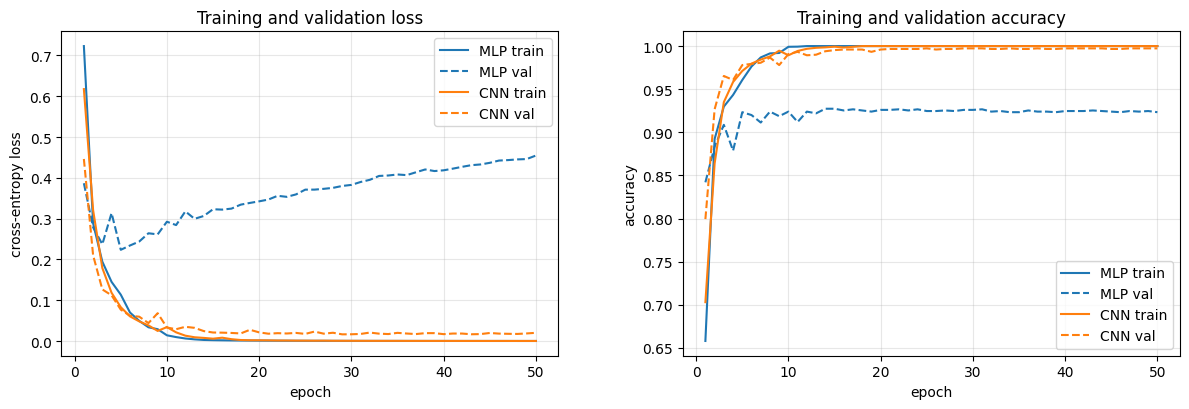

MLP best validation loss at epoch 5: 0.2235
CNN best validation loss at epoch 29: 0.0163


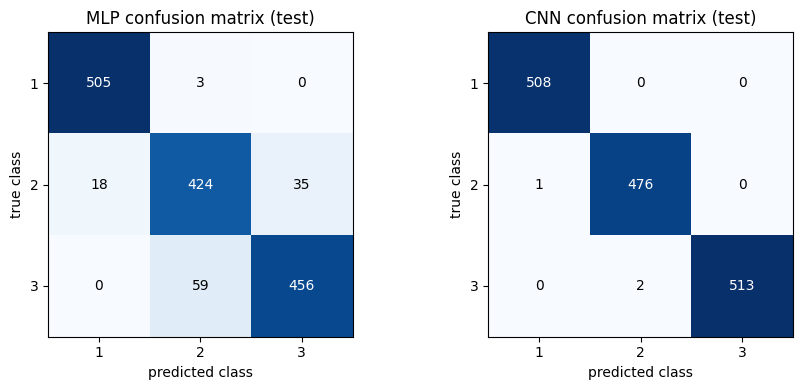

MLP confusion matrix:
 [[505   3   0]
 [ 18 424  35]
 [  0  59 456]]

CNN confusion matrix:
 [[508   0   0]
 [  1 476   0]
 [  0   2 513]]


In [11]:
# ------ Training and validation curves ------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
epochs = np.arange(1, n_epochs + 1)

axes[0].plot(epochs, mlp_train_losses, color='C0', label='MLP train')
axes[0].plot(epochs, mlp_val_losses,   color='C0', linestyle='--', label='MLP val')
axes[0].plot(epochs, cnn_train_losses, color='C1', label='CNN train')
axes[0].plot(epochs, cnn_val_losses,   color='C1', linestyle='--', label='CNN val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('cross-entropy loss')
axes[0].set_title('Training and validation loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, mlp_train_acc, color='C0', label='MLP train')
axes[1].plot(epochs, mlp_val_acc,   color='C0', linestyle='--', label='MLP val')
axes[1].plot(epochs, cnn_train_acc, color='C1', label='CNN train')
axes[1].plot(epochs, cnn_val_acc,   color='C1', linestyle='--', label='CNN val')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy')
axes[1].set_title('Training and validation accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.subplots_adjust(wspace=0.25)
plt.show()
mlp_best = int(np.argmin(mlp_val_losses)) + 1
cnn_best = int(np.argmin(cnn_val_losses)) + 1
print(f"MLP best validation loss at epoch {mlp_best}: {mlp_val_losses[mlp_best-1]:.4f}")
print(f"CNN best validation loss at epoch {cnn_best}: {cnn_val_losses[cnn_best-1]:.4f}")

# ------ Confusion matrices on the test set ------
def confusion_matrix(model, loader, n_classes=3):
    model.eval()
    cm = np.zeros((n_classes, n_classes), dtype=int)
    with torch.no_grad():
        for X, y in loader:
            predicted_class = torch.argmax(model.forward(X), dim=1)
            for t, p in zip(y.numpy(), predicted_class.numpy()):
                cm[t, p] = cm[t, p] + 1
    return cm

cm_mlp = confusion_matrix(mlp, test_loader)
cm_cnn = confusion_matrix(cnn, test_loader)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, cm, name in [(axes[0], cm_mlp, 'MLP'), (axes[1], cm_cnn, 'CNN')]:
    ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{name} confusion matrix (test)')
    ax.set_xticks([0, 1, 2]); ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(['1', '2', '3']); ax.set_yticklabels(['1', '2', '3'])
    ax.set_xlabel('predicted class'); ax.set_ylabel('true class')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.show()

print("MLP confusion matrix:\n", cm_mlp)
print("\nCNN confusion matrix:\n", cm_cnn)

In [12]:
# ---------------------------------------------------------------------------
# Diagnostic: does annulus presence affect classification accuracy?
#
# The annulus is the only shape in the bank with a topological hole, so it
# is a natural test of whether each model has learned a feature that is
# robust to internal cavities. A model relying on aggregate foreground pixel
# mass should under-count annuli relative to filled shapes whereas a model with
# local edge sensitivity should be unaffected. We stratify by hole size
# because a 1-pixel hole barely changes pixel mass while a 10+ pixel hole
# does so substantially.
# ---------------------------------------------------------------------------

from scipy.ndimage import binary_fill_holes


def has_annulus(img):
    # An annulus is detectable by binary_fill_holes: filling enclosed
    # background regions increases the foreground pixel count if and only if
    # at least one shape has a hole.
    return binary_fill_holes(img > 0).sum() > (img > 0).sum()


def hole_pixel_count(img):
    # Number of background pixels enclosed by foreground - i.e. the total
    # area of all holes across all shapes in the image.
    return int(binary_fill_holes(img > 0).sum() - (img > 0).sum())


def subset_accuracy(model, mask):
    # Evaluate a model on the subset of the test set selected by `mask`.
    # Single forward pass, batched, no Python loop over images.
    model.eval()
    images = torch.tensor(np.stack(test_set.images)[mask]).unsqueeze(1)
    labels = torch.tensor(test_set.labels[mask], dtype=torch.long)
    with torch.no_grad():
        preds = torch.argmax(model.forward(images), dim=1)
    return (preds == labels).float().mean().item()


# Compute hole sizes for every test image. Non-annulus images return 0.
hole_sizes = np.array([hole_pixel_count(im) for im in test_set.images])
annulus_mask = hole_sizes > 0

# Headline comparison: any annulus vs. no annulus.
print("Annulus presence (any hole size):")
print(f"  with annulus    (n = {annulus_mask.sum():>4})  "
      f"MLP = {subset_accuracy(mlp, annulus_mask):.3f}, "
      f"CNN = {subset_accuracy(cnn, annulus_mask):.3f}")
print(f"  without annulus (n = {(~annulus_mask).sum():>4})  "
      f"MLP = {subset_accuracy(mlp, ~annulus_mask):.3f}, "
      f"CNN = {subset_accuracy(cnn, ~annulus_mask):.3f}")

# Stratified comparison: hole size determines how much the annulus actually
# departs from a solid shape in pixel-mass terms. Small (1-4 px) holes look
# almost like a filled disk; medium (5-9 px) holes are noticeable; large
# (10+ px) holes substantially reduce foreground pixel count relative to a
# filled shape of the same outer radius.
print("\nAnnulus images stratified by hole size:")
for label, lo, hi in [('small  (1-4 px)',   1,   5),
                      ('medium (5-9 px)',   5,  10),
                      ('large  (10+ px)',  10, 1000)]:
    mask = (hole_sizes >= lo) & (hole_sizes < hi)
    if mask.sum() == 0:
        continue
    print(f"  {label:<18}(n = {mask.sum():>4})  "
          f"MLP = {subset_accuracy(mlp, mask):.3f}, "
          f"CNN = {subset_accuracy(cnn, mask):.3f}")

Annulus presence (any hole size):
  with annulus    (n =  359)  MLP = 0.916, CNN = 0.997
  without annulus (n = 1141)  MLP = 0.926, CNN = 0.998

Annulus images stratified by hole size:
  small  (1-4 px)   (n =  178)  MLP = 0.933, CNN = 0.994
  medium (5-9 px)   (n =  162)  MLP = 0.907, CNN = 1.000
  large  (10+ px)   (n =   19)  MLP = 0.842, CNN = 1.000


## 4. Evaluate performance under distribution shift

In addition to evaluating your models on a standard test set, you should design and generate a second test set that introduces a distribution shift relative to your training data. This means that the new test data should differ in a systematic way (e.g. larger shapes, increased noise, different shape types, more crowded scenes, or thinner connections between shapes, etc), while still following the same underlying task.

You should clearly describe the changes you introduced and justify why they constitute a meaningful shift. Evaluate your trained models on this new test set and compare the results with those obtained on the original test set. Comment on how performance changes and provide an explanation for any observed differences. Your analysis should include at least one example where the model fails under the shifted distribution.

In [13]:
def add_salt_noise(img, prob=0.02):
    """
    Flip background pixels to 1 with probability `prob`. Under 4-connectivity
    each isolated noise pixel is itself a connected component, which directly
    tests whether the model counts real shapes or any connected blobs.
    """
    noisy = img.copy()
    mask = (np.random.rand(*img.shape) < prob) & (img == 0)
    noisy[mask] = 1.0
    return noisy


def apply_blur(img, sigma=1.0, threshold=0.3):
    """
    Gaussian blur followed by re-binarisation. Simulates out-of-focus imaging.
    Heavy blur merges nearby shapes and can change the underlying count.
    """
    blurred = gaussian_filter(img.astype(np.float32), sigma=sigma)
    return (blurred >= threshold).astype(np.float32)


def apply_scale(img, scale=0.6):
    """
    Down-scale the image and centre-pad with zeros. Simulates a zoomed-out
    view. Tests the lack of scale equivariance in standard CNNs.
    """
    H, W = img.shape
    new_h = max(1, int(H*scale))
    new_w = max(1, int(W*scale))
    small = zoom(img, (new_h/H, new_w/W), order=0)   # nearest-neighbour keeps binary
    canvas = np.zeros_like(img)
    y0 = (H - new_h)//2
    x0 = (W - new_w)//2
    canvas[y0:y0+new_h, x0:x0+new_w] = small
    return canvas


def apply_clip(img, clip_frac=0.3, min_keep_frac=0.25):
    """
    Zero out a strip that cuts into the shapes' bounding box. Simulates the
    camera framing slightly wrong. The clip is pulled back if it would erase
    any original shape below `min_keep_frac` of its pixels.
    """
    if img.sum() == 0:
        return img.copy()

    labels, n = cc_label((img > 0).astype(np.uint8), structure=struct_4)
    orig_sizes = np.array([(labels == k).sum() for k in range(1, n+1)])

    ys, xs = np.where(img > 0)
    top, bot, lef, rig = ys.min(), ys.max(), xs.min(), xs.max()
    H, W = img.shape
    side = random.choice(['top', 'bottom', 'left', 'right'])

    def try_clip(w):
        out = img.copy()
        if   side == 'top':    out[:w, :]  = 0
        elif side == 'bottom': out[-w:, :] = 0
        elif side == 'left':   out[:, :w]  = 0
        elif side == 'right':  out[:, -w:] = 0
        return out

    if side == 'top':
        w = top + int((bot - top + 1) * clip_frac)
    elif side == 'bottom':
        w = H - bot - 1 + int((bot - top + 1) * clip_frac)
    elif side == 'left':
        w = lef + int((rig - lef + 1) * clip_frac)
    elif side == 'right':
        w = W - rig - 1 + int((rig - lef + 1) * clip_frac)

    # Pull back the strip until every original shape retains min_keep_frac
    for _ in range(w + 1):
        candidate = try_clip(w)
        survived = np.array([((labels == k) & (candidate > 0)).sum()
                             for k in range(1, n+1)])
        if np.all(survived >= min_keep_frac * orig_sizes):
            return candidate
        w = w - 1
        if w < 0:
            break
    return img.copy()


class ShiftedDataset(Dataset):
    # Wraps generate_image + a user-supplied shift function. The shift is
    # applied AFTER generation so the label (number of shapes drawn) is
    # still correct by the original definition.
    def __init__(self, n_samples, shift_fn, size=32):
        self.images = []
        self.labels = []
        self.classes = ['1', '2', '3']

        for _ in range(n_samples):
            n_shapes = random.randint(1, 3)
            img, label = generate_image(size=size, n_shapes=n_shapes)
            img = shift_fn(img)
            self.images.append(img.astype(np.float32))
            self.labels.append(label)

        self.images = np.array(self.images)
        self.labels = np.array(self.labels)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x = torch.tensor(self.images[idx]).unsqueeze(0)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

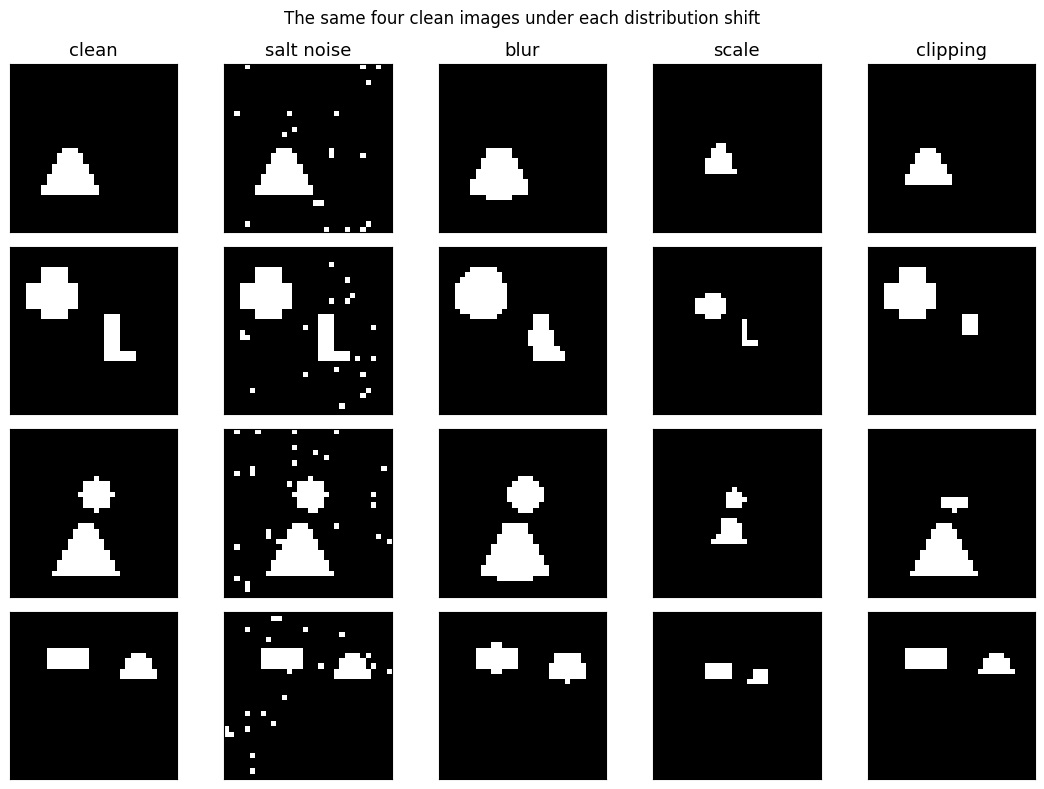

In [14]:
# Build all shifted test sets - different seeds so each is distinct and reproducible
random.seed(42); np.random.seed(42)
shift_noise = ShiftedDataset(1500, lambda im: add_salt_noise(im, prob=0.02))
random.seed(43); np.random.seed(43)
shift_blur  = ShiftedDataset(1500, lambda im: apply_blur(im, sigma=1.0))
random.seed(44); np.random.seed(44)
shift_scale = ShiftedDataset(1500, lambda im: apply_scale(im, scale=0.6))
random.seed(45); np.random.seed(45)
shift_clip  = ShiftedDataset(1500, lambda im: apply_clip(im, clip_frac=0.3, min_keep_frac=0.25))

shifted_sets = {
    'salt noise':   shift_noise,
    'blur':         shift_blur,
    'scale':        shift_scale,
    'clipping':     shift_clip,
}
shifted_loaders = {name: torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False)
                   for name, ds in shifted_sets.items()}

# Show the same four images under the four transform-based shifts
random.seed(100); np.random.seed(100)
clean_imgs = [generate_image(32, random.randint(1, 3))[0] for _ in range(4)]
rows = [('clean',      clean_imgs),
        ('salt noise', [add_salt_noise(im, 0.02) for im in clean_imgs]),
        ('blur',       [apply_blur(im, sigma=1.0) for im in clean_imgs]),
        ('scale',      [apply_scale(im, scale=0.6) for im in clean_imgs]),
        ('clipping',   [apply_clip(im, clip_frac=0.3, min_keep_frac=0.25) for im in clean_imgs])]
fig, axes = plt.subplots(4, 5, figsize=(11, 8))
for col, (name, imgs) in enumerate(rows):
    for row, im in enumerate(imgs):
        axes[row, col].imshow(im, cmap='gray', vmin=0, vmax=1)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
    axes[0, col].set_title(name, fontsize=13)
plt.suptitle('The same four clean images under each distribution shift')
plt.tight_layout()
plt.savefig('Image_Distribution_Shift.png', dpi=150, bbox_inches='tight')
plt.show()


Model             original  salt noise        blur       scale    clipping
--------------------------------------------------------------------------
MLP (clean)          0.923       0.571       0.923       0.473       0.801
CNN (clean)          0.998       0.322       0.931       0.665       0.955


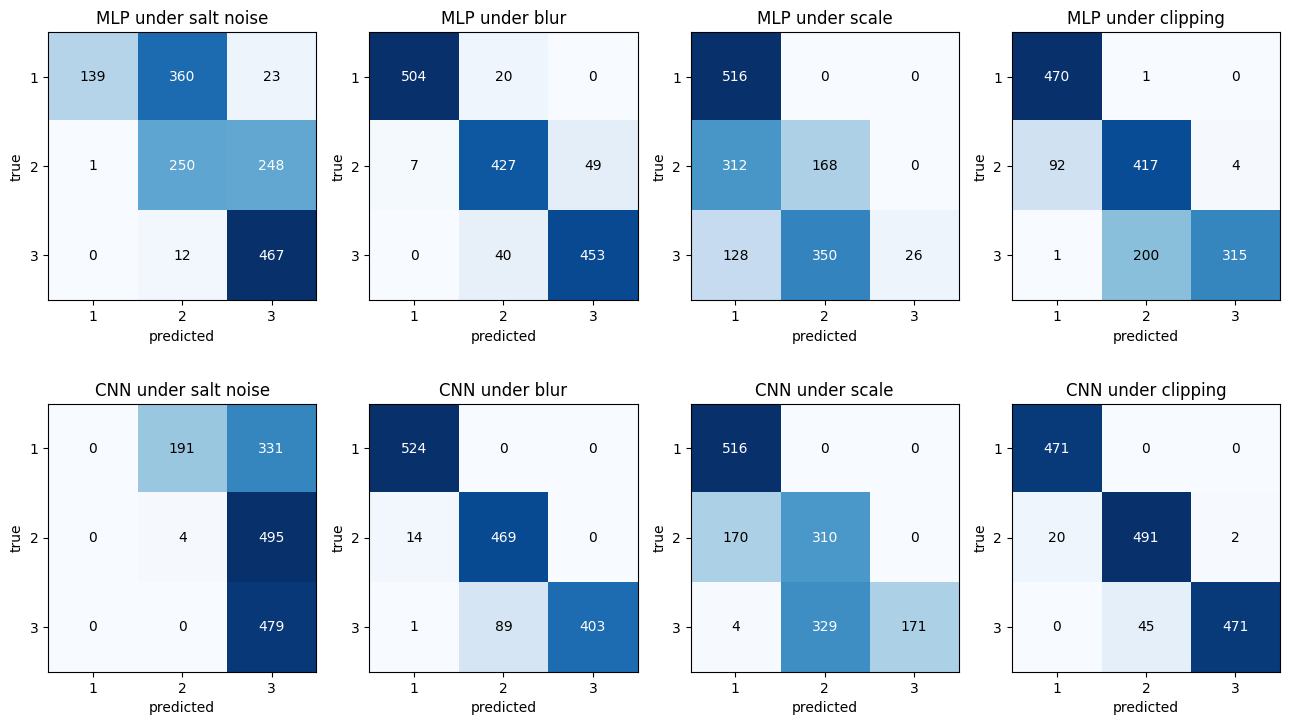

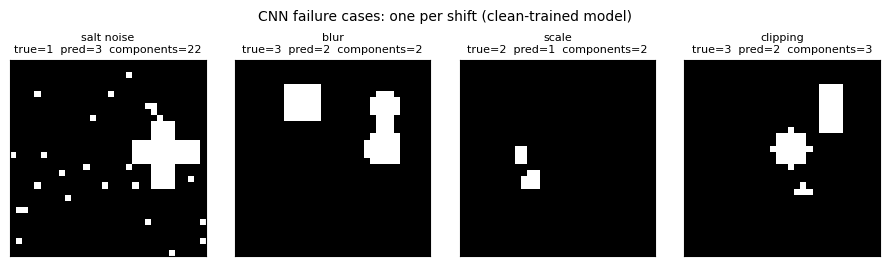

In [15]:
results = {}
for name, mdl in [('MLP (clean)', mlp), ('CNN (clean)', cnn)]:
    row = {'original': evaluate(mdl, test_loader)}
    for sname, ldr in shifted_loaders.items():
        row[sname] = evaluate(mdl, ldr)
    results[name] = row

shift_names = ['original'] + list(shifted_loaders.keys())
header = f"{'Model':<14}" + "".join(f"{k:>12}" for k in shift_names)
print(header); print("-"*len(header))
for name, row in results.items():
    print(f"{name:<14}" + "".join(f"{row[k]:>12.3f}" for k in shift_names))

# ---------------------------------------------------------------------------
# Combined confusion-matrix figure: clean MLP (top row) and clean CNN
# (bottom row) under each of the four distribution shifts.
# ---------------------------------------------------------------------------

mlp_shift_cms = {name: confusion_matrix(mlp, ldr) for name, ldr in shifted_loaders.items()}
shift_cms      = {name: confusion_matrix(cnn, ldr) for name, ldr in shifted_loaders.items()}

fig, axes = plt.subplots(2, 4, figsize=(13, 7.2))

for col, name in enumerate(shifted_loaders.keys()):
    for row, (model_name, cms) in enumerate([('MLP', mlp_shift_cms),
                                              ('CNN', shift_cms)]):
        ax = axes[row, col]
        cm = cms[name]
        ax.imshow(cm, cmap='Blues')
        ax.set_title(f'{model_name} under {name}', fontsize=12)
        ax.set_xticks([0, 1, 2]); ax.set_yticks([0, 1, 2])
        ax.set_xticklabels(['1', '2', '3']); ax.set_yticklabels(['1', '2', '3'])
        ax.set_xlabel('predicted'); ax.set_ylabel('true')
        for i in range(3):
            for j in range(3):
                ax.text(j, i, cm[i, j], ha='center', va='center',
                        color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.savefig('Confusion_Matrices_Under_Shift.png', dpi=150, bbox_inches='tight')
plt.show()

# ------ Failure case per shift (clean-trained CNN) ------
cnn.eval()
fig, axes = plt.subplots(1, 4, figsize=(9, 2.8))
for ax, (sname, dset) in zip(axes, shifted_sets.items()):
    for i in range(len(dset)):
        X, y = dset[i]
        with torch.no_grad():
            pred = torch.argmax(cnn.forward(X.unsqueeze(0)), dim=1).item()
        if pred != y.item():
            img = dset.images[i]
            n_comp = count_components_4(img)
            ax.imshow(img, cmap='gray', vmin=0, vmax=1)
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_title(f'{sname}\ntrue={y.item()+1}  pred={pred+1}  '
                         f'components={n_comp}', fontsize=8)
            break
plt.suptitle('CNN failure cases: one per shift (clean-trained model)', fontsize=10)
plt.tight_layout()
plt.subplots_adjust(wspace=0.15)
plt.show()

Now you should attempt to improve generalisation of your model. 

You are encouraged to make changes to the model or training procedure (e.g. architecture, regularisation, hyperparameters), so that the performance on the shifted dataset is better even if you only train on the original dataset.

Approaches that rely solely on retraining with data drawn from the shifted distribution will receive limited credit unless accompanied by a clear and thoughtful analysis.

In [16]:
class AugmentedDataset(Dataset):
    """
    Wraps ComponentsDataset and applies a random mix of mild noise / blur /
    scale / clipping at each __getitem__. Augmentation parameter ranges
    are deliberately MILDER than the test-time shifts so the model never
    sees the shifted test distribution directly.
    """
    def __init__(self, base_dataset, p_each=0.5,
                 max_noise=0.02, max_sigma=0.8,
                 min_scale=0.85, max_clip_frac=0.2):
        self.base = base_dataset
        self.p_each = p_each
        self.max_noise = max_noise
        self.max_sigma = max_sigma
        self.min_scale = min_scale
        self.max_clip_frac = max_clip_frac

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img = self.base.images[idx].copy()
        lab = self.base.labels[idx]

        if random.random() < self.p_each:
            img = add_salt_noise(img, prob=np.random.uniform(0, self.max_noise))
        if random.random() < self.p_each:
            img = apply_blur(img, sigma=np.random.uniform(0.3, self.max_sigma))
        if random.random() < self.p_each:
            img = apply_scale(img, scale=np.random.uniform(self.min_scale, 1.0))
        if random.random() < self.p_each:
            img = apply_clip(img,
                             clip_frac=np.random.uniform(0.1, self.max_clip_frac),
                             min_keep_frac=0.3)

        x = torch.tensor(img).unsqueeze(0)
        y = torch.tensor(lab, dtype=torch.long)
        return x, y


aug_train = AugmentedDataset(train_set)
aug_loader = torch.utils.data.DataLoader(aug_train, batch_size=batch_size, shuffle=True)

# Same training procedure as the clean baseline, only the data loader changes.
for arch_name, build_model in [('MLP', MLP), ('CNN', CNN)]:
    random.seed(0); np.random.seed(0); torch.manual_seed(0)
    model = build_model()
    optimiser = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses = [], []
    train_acc, val_acc = [], []

    pbar = tqdm(range(n_epochs), desc=f'[{arch_name}-aug]', leave=True)
    for n in pbar:
        model.train()
        tot_train_loss = 0
        train_correct = 0
        for X, y in aug_loader:
            model_pred = model.forward(X)
            loss_value = loss(model_pred, y)
            tot_train_loss = tot_train_loss + loss_value.item() * X.shape[0]
            loss_value.backward()
            optimiser.step()
            optimiser.zero_grad()
            predicted_class = torch.argmax(model_pred, dim=1)
            matches = torch.eq(predicted_class, y)
            train_correct = train_correct + torch.sum(matches.float())

        model.eval()
        tot_val_loss = 0
        val_correct = 0
        with torch.no_grad():
            for X, y in val_loader:
                model_pred = model.forward(X)
                loss_value = loss(model_pred, y)
                tot_val_loss = tot_val_loss + loss_value.item() * X.shape[0]
                predicted_class = torch.argmax(model_pred, dim=1)
                matches = torch.eq(predicted_class, y)
                val_correct = val_correct + torch.sum(matches.float())

        train_loss = tot_train_loss / len(aug_loader.dataset)
        val_loss   = tot_val_loss   / len(val_loader.dataset)
        train_accuracy = train_correct.item() / len(aug_loader.dataset)
        val_accuracy   = val_correct.item()   / len(val_loader.dataset)

        train_losses.append(train_loss); val_losses.append(val_loss)
        train_acc.append(train_accuracy); val_acc.append(val_accuracy)

        pbar.set_postfix({
            'train_loss': f'{train_loss:.3f}',
            'val_loss':   f'{val_loss:.3f}',
            'val_acc':    f'{val_accuracy:.3f}',
        })

    if arch_name == 'MLP':
        mlp_aug = model
        mlp_aug_train_losses, mlp_aug_val_losses = train_losses, val_losses
        mlp_aug_train_acc, mlp_aug_val_acc = train_acc, val_acc
    else:
        cnn_aug = model
        cnn_aug_train_losses, cnn_aug_val_losses = train_losses, val_losses
        cnn_aug_train_acc, cnn_aug_val_acc = train_acc, val_acc


[CNN-aug]: 100%|██████████| 50/50 [01:43<00:00,  2.06s/it, train_loss=0.038, val_loss=0.006, val_acc=0.999]


In [17]:
# Regularised model variants combining dropout and batch normalisation.
# BatchNorm is applied immediately after each linear/conv layer (before the
# nonlinearity); Dropout is applied after the activation in the classifier
# path so it never sees dead ReLU outputs.
class MLPReg(nn.Module):
    def __init__(self, p=0.3):
        super().__init__()
        self.input  = nn.Linear(32*32, 128)
        self.bn1    = nn.BatchNorm1d(128)
        self.hidden = nn.Linear(128, 64)
        self.bn2    = nn.BatchNorm1d(64)
        self.output = nn.Linear(64, 3)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=p)

    def forward(self, x):
        x = x.reshape(x.shape[0], -1)
        x = self.dropout(self.relu(self.bn1(self.input(x))))
        x = self.dropout(self.relu(self.bn2(self.hidden(x))))
        x = self.output(x)
        return x


class CNNReg(nn.Module):
    def __init__(self, p=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(1,  16, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(32)
        self.maxpool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(32*8*8, 64)
        self.bn_fc = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 3)
        self.dropout = nn.Dropout(p=p)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.maxpool(self.relu(self.bn2(self.conv2(x))))
        x = x.reshape(x.shape[0], -1)
        x = self.dropout(self.relu(self.bn_fc(self.fc1(x))))
        x = self.fc2(x)
        return x


# Training loop with checkpointing and early stopping on validation loss.
patience = 10

for arch_name, build_model, ckpt_path in [
    ('MLP-reg', lambda: MLPReg(p=0.3), 'top_mlp_reg.pt'),
    ('CNN-reg', lambda: CNNReg(p=0.3), 'top_cnn_reg.pt'),
]:
    random.seed(0); np.random.seed(0); torch.manual_seed(0)
    model = build_model()
    optimiser = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses = [], []
    train_acc, val_acc = [], []

    min_val_loss = 1e5
    best_epoch = 0
    stale = 0

    pbar = tqdm(range(n_epochs), desc=f'[{arch_name}]', leave=True)
    for n in pbar:
        # Training step
        model.train()
        tot_train_loss = 0
        train_correct = 0
        for X, y in train_loader:
            model_pred = model.forward(X)
            loss_value = loss(model_pred, y)
            tot_train_loss = tot_train_loss + loss_value.item() * X.shape[0]
            loss_value.backward()
            optimiser.step()
            optimiser.zero_grad()
            predicted_class = torch.argmax(model_pred, dim=1)
            matches = torch.eq(predicted_class, y)
            train_correct = train_correct + torch.sum(matches.float())

        # Validation step
        model.eval()
        tot_val_loss = 0
        val_correct = 0
        with torch.no_grad():
            for X, y in val_loader:
                model_pred = model.forward(X)
                loss_value = loss(model_pred, y)
                tot_val_loss = tot_val_loss + loss_value.item() * X.shape[0]
                predicted_class = torch.argmax(model_pred, dim=1)
                matches = torch.eq(predicted_class, y)
                val_correct = val_correct + torch.sum(matches.float())

        train_loss = tot_train_loss / len(train_loader.dataset)
        val_loss   = tot_val_loss   / len(val_loader.dataset)
        train_accuracy = train_correct.item() / len(train_loader.dataset)
        val_accuracy   = val_correct.item()   / len(val_loader.dataset)

        train_losses.append(train_loss); val_losses.append(val_loss)
        train_acc.append(train_accuracy); val_acc.append(val_accuracy)

        # Checkpoint if validation loss has improved
        if val_loss < min_val_loss:
            min_val_loss = val_loss
            best_epoch = n + 1
            torch.save(model.state_dict(), ckpt_path)
            stale = 0
        else:
            stale = stale + 1

        pbar.set_postfix({
            'train_loss': f'{train_loss:.3f}',
            'val_loss':   f'{val_loss:.3f}',
            'val_acc':    f'{val_accuracy:.3f}',
            'best_epoch': best_epoch,
        })

        # Early stopping
        if stale >= patience:
            pbar.close()
            print(f"[{arch_name}] Early stopping at epoch {n+1}. "
                  f"Best epoch = {best_epoch} (val loss {min_val_loss:.4f})")
            break

    # Restore best-seen weights
    model.load_state_dict(torch.load(ckpt_path, weights_only=True))

    if arch_name == 'MLP-reg':
        mlp_reg = model
        mlp_reg_train_losses, mlp_reg_val_losses = train_losses, val_losses
        mlp_reg_train_acc, mlp_reg_val_acc = train_acc, val_acc
    else:
        cnn_reg = model
        cnn_reg_train_losses, cnn_reg_val_losses = train_losses, val_losses
        cnn_reg_train_acc, cnn_reg_val_acc = train_acc, val_acc


[MLP-reg]:  60%|██████    | 30/50 [00:05<00:03,  5.63it/s, train_loss=0.101, val_loss=0.282, val_acc=0.901, best_epoch=21]


[MLP-reg] Early stopping at epoch 31. Best epoch = 21 (val loss 0.2601)


[CNN-reg]:  98%|█████████▊| 49/50 [01:32<00:01,  1.89s/it, train_loss=0.004, val_loss=0.002, val_acc=0.999, best_epoch=40]

[CNN-reg] Early stopping at epoch 50. Best epoch = 40 (val loss 0.0004)


Model             original  salt noise        blur       scale    clipping
--------------------------------------------------------------------------
MLP (clean)          0.923       0.571       0.923       0.473       0.801
CNN (clean)          0.998       0.322       0.931       0.665       0.955
MLP (+ aug)          0.919       0.885       0.920       0.619       0.833
CNN (+ aug)          0.999       0.992       0.966       0.869       0.971
MLP (+ reg)          0.902       0.843       0.897       0.405       0.722
CNN (+ reg)          1.000       0.319       0.921       0.780       0.992


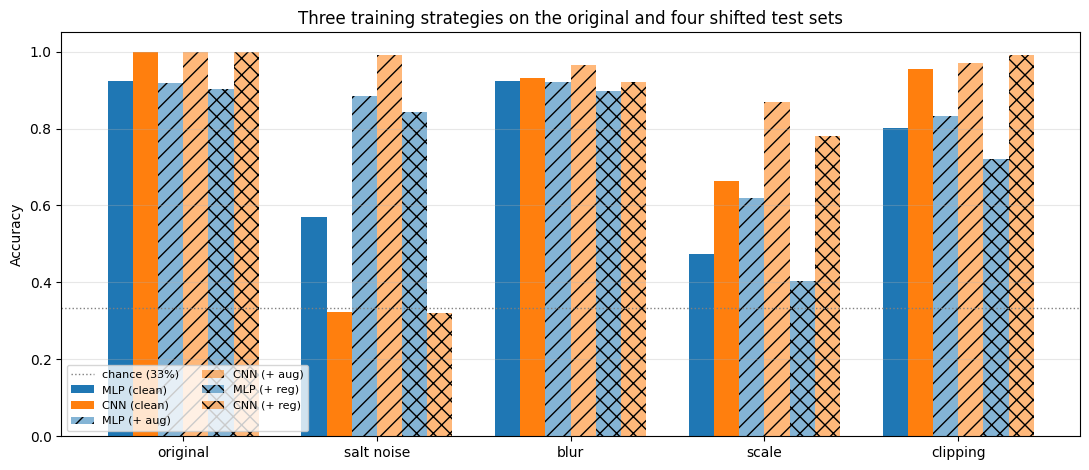

In [18]:
for name, mdl in [('MLP (+ aug)', mlp_aug), ('CNN (+ aug)', cnn_aug),
                  ('MLP (+ reg)', mlp_reg), ('CNN (+ reg)', cnn_reg)]:
    row = {'original': evaluate(mdl, test_loader)}
    for sname, ldr in shifted_loaders.items():
        row[sname] = evaluate(mdl, ldr)
    results[name] = row

shift_names = ['original'] + list(shifted_loaders.keys())
header = f"{'Model':<14}" + "".join(f"{k:>12}" for k in shift_names)
print(header); print("-"*len(header))
for name, row in results.items():
    print(f"{name:<14}" + "".join(f"{row[k]:>12.3f}" for k in shift_names))


# ------ Summary bar chart ------
x = np.arange(len(shift_names))
width = 0.13
fig, ax = plt.subplots(figsize=(11, 4.8))

bar_specs = [
    ('MLP (clean)',  -2.5, 'C0', 1.0,  None),
    ('CNN (clean)',  -1.5, 'C1', 1.0,  None),
    ('MLP (+ aug)',  -0.5, 'C0', 0.55, '//'),
    ('CNN (+ aug)',   0.5, 'C1', 0.55, '//'),
    ('MLP (+ reg)',   1.5, 'C0', 0.55, 'xx'),
    ('CNN (+ reg)',   2.5, 'C1', 0.55, 'xx'),
]
for name, off, col, alpha, hatch in bar_specs:
    vals = [results[name][k] for k in shift_names]
    ax.bar(x + off*width, vals, width, label=name, color=col, alpha=alpha, hatch=hatch)

ax.axhline(1/3, linestyle=':', color='gray', linewidth=1, label='chance (33%)')
ax.set_xticks(x); ax.set_xticklabels(shift_names)
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.05)
ax.set_title('Three training strategies on the original and four shifted test sets')
ax.legend(loc='lower left', fontsize=8, ncol=2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()